In [5]:
import pandas as pd
df=pd.read_csv("netflix_titles.csv")
print("dataset loaded succesfully!")
print("rows and columns:",df.shape)
df.head()

dataset loaded succesfully!
rows and columns: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [8]:
df.duplicated().sum()
print("duplicates before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("duplicates after:", df.duplicated().sum())

duplicates before: 0
duplicates after: 0


This dataset is about Movies and TV Shows that're on Netflix. It has things like the title of the Movies and TV Shows the director, the cast, the country where they were made the year they were released the rating how long they're what category they fit into. When I looked at the dataset I saw that it has 8,807 records and 12 columns. The Netflix dataset has some spaces in some of the columns but there are no records that are exactly the same. I will look at the Netflix data some more to see what trends I can find in the Movies and TV Shows on Netflix and to find some information, about Netflix Movies and TV Shows.

In [9]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,4
duration,3


In [10]:
df['date_added'] = df['date_added'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')
df['duration'] = df['duration'].fillna('Unknown')
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [11]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [12]:
df.duplicated().sum()

np.int64(0)

Data Cleaning Decisions

Before I started analyzing the data I checked it for missing information and duplicate entries. I found values in columns like director, cast, country, date_added, rating and duration. I decided to fill the gaps with labels like "Unknown" and "Not Rated" instead of getting rid of those records. That way I did not lose any data. I also looked for entries but I did not find any. After cleaning I successfully handled all the missing values. The dataset was ready, for further analysis.

In [13]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


Observation(for the above code) The dataset contains more Movies than TV Shows. There are 6,131 Movies and 2,676 TV Shows are present on Netflix. Netflix has a major focus on movies compared to television shows




In [14]:
df['country'].value_counts().head(10)

,count
country,
United States,2818
India,972
Unknown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


Observation

The United States contributes the highest number of titles on Netflix with 2,818 entries. India is the second-largest contributor with 972 titles. This indicates that Netflix relies heavily on content from the United States while also maintaining a strong presence in the Indian market.

In [15]:
df['release_year'].value_counts().head(10)

,count
release_year,
2018,1147
2017,1032
2019,1030
2020,953
2016,902
2021,592
2015,560
2014,352
2013,288


Observation

The year 2018 has the highest number of titles with 1,147 releases. The years 2017 and 2019 also show a large number of content. This indicates that Netflix experienced significant growth in content production between 2017 and 2020.

In [16]:
df['rating'].value_counts().head(10)

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


observation
 TV-MA is the most common rating on Netflix with 3,207 titles, followed by TV-14 with 2,160 titles.a large portion of Netflix content is targeted towards teenagers and mature audiences. Family-friendly ratings such as TV-Y and TV-G are available but appear less frequently in the dataset.




In [17]:
df['listed_in'].value_counts().head(10)

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
Kids' TV,220
Children & Family Movies,215
"Children & Family Movies, Comedies",201
"Documentaries, International Movies",186


observation The most common genre category in the dataset is "Dramas, International Movies" with 362 titles, followed closely by documentaries and Stand-Up Comedy. Netflix offers a wide variety of drama-based and international content. The popularity of documentaries also indicates growing viewer interest in educational and real-world topics




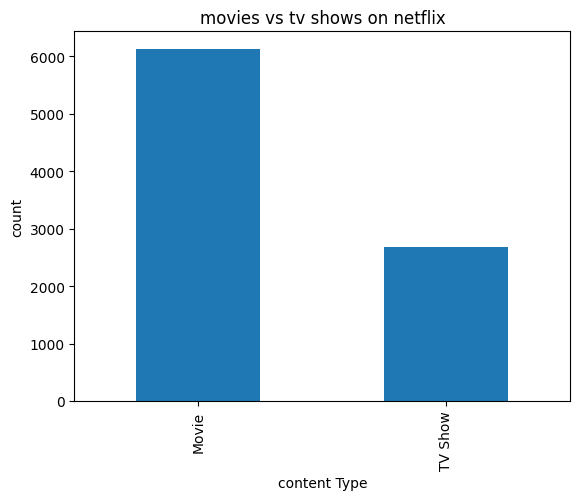

In [18]:
import matplotlib.pyplot as plt
df['type'].value_counts().plot(kind='bar')
plt.title('movies vs tv shows on netflix')
plt.xlabel('content Type')
plt.ylabel('count')
plt.show()

The bar chart clearly shows that Movies are available in larger numbers than TV Shows. This indicates that Netflix focuses more on movies compared to television series.




In [19]:
import pandas as pd
df = pd.read_csv("netflix_titles.csv")

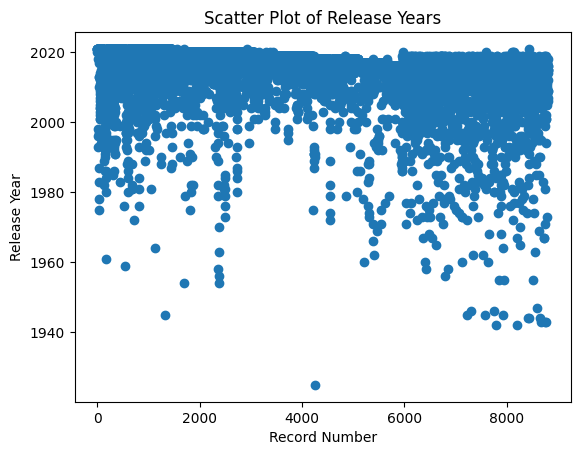

In [20]:
import matplotlib.pyplot as plt
plt.scatter(df.index, df['release_year'])
plt.title('Scatter Plot of Release Years')
plt.xlabel('Record Number')
plt.ylabel('Release Year')
plt.show()

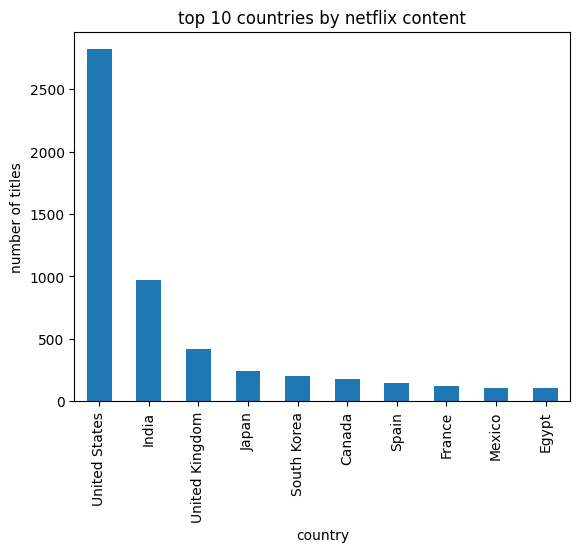

In [21]:
import matplotlib.pyplot as plt
df['country'].value_counts().head(10).plot(kind='bar')
plt.title('top 10 countries by netflix content')
plt.xlabel('country')
plt.ylabel('number of titles')
plt.show()

The United States havibg highest number of titles, while India holds the second position. This highlights the importance of these countries in Netflix's content library.

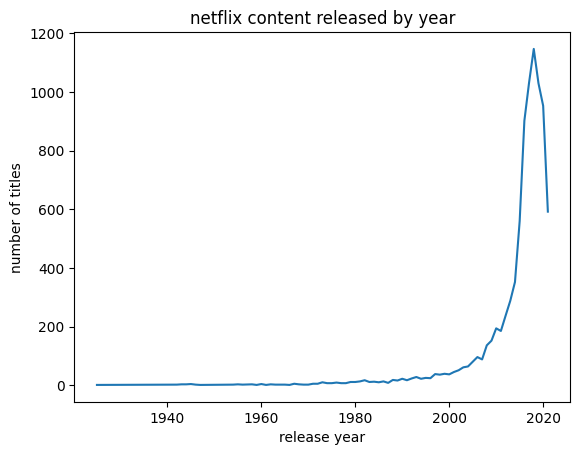

In [22]:
import matplotlib.pyplot as plt
df['release_year'].value_counts().sort_index().plot(kind='line')
plt.title("netflix content released by year")
plt.xlabel('release year')
plt.ylabel('number of titles')
plt.show()

The number of titles released on Netflix increased significantly after 2015 and reached a peak around 2018. This indicates a period of rapid content expansion on the platform.



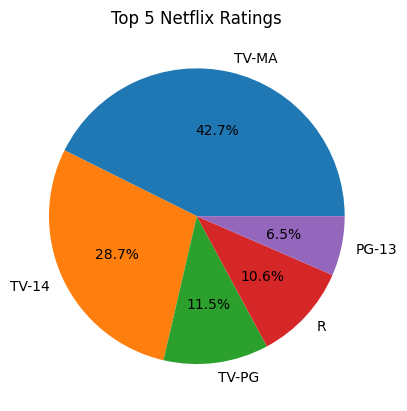

In [23]:
df['rating'].value_counts().head(5).plot(
    kind='pie',autopct='%1.1f%%'
)
plt.title('Top 5 Netflix Ratings')
plt.ylabel('')
plt.show()

pie chart

TV-MA occupies the largest portion of the chart, showing that mature-audience content and teeneger forms a major part of Netflix's catalog.




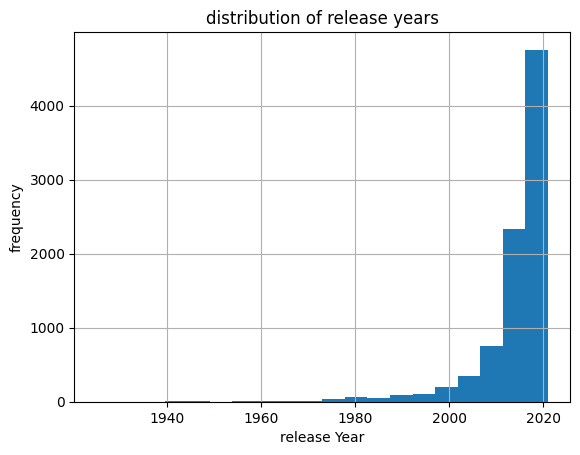

In [24]:
import matplotlib.pyplot as plt
df['release_year'].hist(bins=20)
plt.title("distribution of release years")
plt.xlabel('release Year')
plt.ylabel("frequency")
plt.show()

Chart Observation

Most titles belong to recent years, while comparatively fewer titles were released in earlier decades.




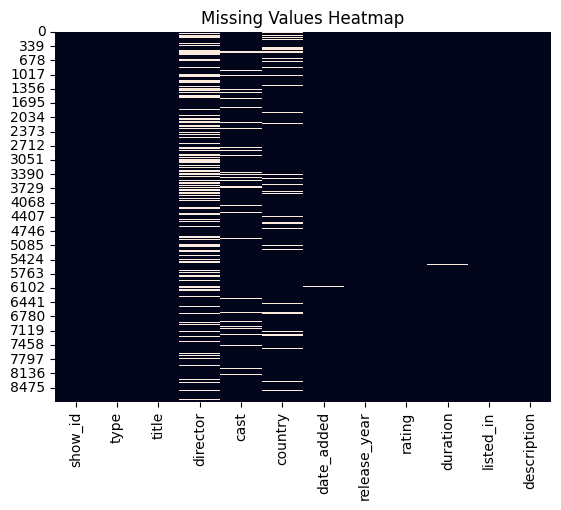

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Values Heatmap')
plt.show()

Chart Observation

The heatmap confirms that missing values were successfully handled during the data cleaning stage, as no major gaps are visible.

The Netflix dataset has 8,807 records and 12 columns. It has information about movies and TV shows on Netflix. This dataset includes details like title,country,director,release year,rating,genre The missing values were removed during cleaning. The dataset is good for checking out the data and making visualizations about movies and TV shows on Netflix. The Netflix dataset is great for understanding what is, on Netflix.



five insights

1.Netflix have more Movies (6131) than TV Shows (2676).stonger on movie content 2.The United States is the largest content producer on Netflix with 2818 titles, followed by India with 972 titles 3.Netflix content releases peaked in 2018 with 1147 titles, showing rapid growth during that period. 4.TV-MA is the most common content rating (3207 titles), indicating a large amount of mature-audience content. 5.Drama and International Movie categories are the most common genres on Netflix, while documentaries and stand-up comedy are also highly represented.

Surprising Finding

The biggest surprise from this analysis was that 2018 had the most content releases on Netflix. I thought recent years would have releases.

Another thing that stood out was the difference between Movies and TV Shows.

These findings gave us ideas, about Netflixs content plan and how it grew over time.s, on Netflix.



I worked on a project where I looked at the Netflix dataset. I found some things about the kind of content they have when it was released how it was rated where it came from and what type of genre it was. The Netflix dataset showed me that Netflix has Movies than TV Shows. I also found out that the United States makes the content, for Netflix.
